# 05 Monte Carlo Simulation

In this notebook I run the first probabilistic simulation of the cascaded cooling system. The aim is to move from the deterministic baseline into a set of repeated sampled operating states, so that overload risk can be estimated for HVAC, CW and FW.

Two uncertainty models are implemented and compared:

* triangular distribution;
* truncated normal distribution.

Both models are applied consistently across all subsystems, scenarios and uncertainty cases. I keep the sampled rows independent in this notebook, because dependency modelling is treated separately in Notebook 06.


## Method summary

The Monte Carlo simulation takes the uncertainty parameter table from Notebook 04 and repeatedly samples possible load values. Each simulation iteration represents one possible operating state of the cooling system.

The process used in each iteration is:

1. Sample each local consumer load from either the triangular or truncated normal distribution.
2. Sum the sampled local HVAC, CW and FW loads separately.
3. Rebuild the cascade so that HVAC is passed into CW and the total CW load is passed into FW.
4. Compare each cascaded subsystem load with the available subsystem capacity.
5. Store the overload indicator, spare capacity and load-to-capacity ratio.

I use 100,000 simulations for the main runs. This is large enough to estimate high-percentile values such as P95 and P99 without making the notebook unnecessarily slow. Notebook 08 then checks this choice using the convergence analysis.

The propagation rows are still excluded here. This is important because the Monte Carlo model recomputes the cascade in every iteration; if the embedded propagation rows were also sampled as local loads, the upstream loads would be counted twice.

## Imports and paths


In [1]:
from pathlib import Path
import math
import time
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False

try:
    from scipy.stats import truncnorm
    scipy_available = True
except ModuleNotFoundError:
    scipy_available = False

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (
            (candidate / "data" / "raw" / "data.xlsx").exists()
            and (candidate / "outputs" / "tables" / "uncertainty_distribution_parameters.csv").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not find the project root. Please open VS Code at the repository folder.")


project_root = find_project_root()
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"
tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Tables output path: {tables_output_path}")
print(f"Figures output path: {figures_output_path}")
# Consistent project colours used in all notebook figures
SYSTEM_ORDER = ["HVAC", "CW", "FW"]
SYSTEM_PALETTE = {
    "HVAC": "#7b5aa6",
    "CW": "#3f83a3",
    "FW": "#5f9f77",
    "Ultimate Heat Sink": "#d78b4b",
}
SYSTEM_COLOUR_LIST = [SYSTEM_PALETTE[system] for system in SYSTEM_ORDER]
SCENARIO_PALETTE = {
    "Scenario Alpha": SYSTEM_PALETTE["HVAC"],
    "Scenario Bravo": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DISTRIBUTION_PALETTE = {
    "Triangular": SYSTEM_PALETTE["CW"],
    "Truncated normal": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DEPENDENCY_PALETTE = {
    "Independent": "#6f7b82",
    "Global Gaussian copula": SYSTEM_PALETTE["HVAC"],
    "Subsystem-block Gaussian copula": SYSTEM_PALETTE["CW"],
}



Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Tables output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\tables
Figures output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\figures


## Load simulation inputs


In [2]:
parameter_path = tables_output_path / "uncertainty_distribution_parameters.csv"
baseline_path = tables_output_path / "deterministic_baseline.csv"
excluded_rows_path = tables_output_path / "uncertainty_excluded_propagation_rows.csv"

distribution_parameters = pd.read_csv(parameter_path)
deterministic_baseline = pd.read_csv(baseline_path)
excluded_propagation_rows = pd.read_csv(excluded_rows_path)

system_order = ["HVAC", "CW", "FW"]
scenario_order = ["Scenario Alpha", "Scenario Bravo"]
margin_case_order = [
    "Case A - CUM",
    "Case B - CMM + CUM",
    "Case C - CMM + CUM + DBM + IGM",
]
distribution_order = ["Triangular", "Truncated normal"]

distribution_parameters["system"] = pd.Categorical(
    distribution_parameters["system"],
    categories=system_order,
    ordered=True,
)
distribution_parameters["scenario"] = pd.Categorical(
    distribution_parameters["scenario"],
    categories=scenario_order,
    ordered=True,
)
distribution_parameters["margin_case"] = pd.Categorical(
    distribution_parameters["margin_case"],
    categories=margin_case_order,
    ordered=True,
)

print(f"Distribution parameter rows: {len(distribution_parameters):,}")
print(f"Deterministic baseline rows: {len(deterministic_baseline):,}")
display(distribution_parameters.head())


Distribution parameter rows: 15,534
Deterministic baseline rows: 6


,record_id,source_row,pbs_code,teamcenter_id,bom_id,item_description,system,scenario,margin_case,nominal_load_kw,uncertainty_pct,triangular_lower_kw,triangular_mode_kw,triangular_upper_kw,truncnorm_lower_kw,truncnorm_mean_kw,truncnorm_upper_kw,truncnorm_sigma_kw,is_degenerate
0,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case A - CUM,14.872,0.15,12.6412,14.872,17.1028,12.6412,14.872,17.1028,1.138163,False
1,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case B - CMM + CUM,14.872,0.25,11.1540,14.872,18.5900,11.1540,14.872,18.5900,1.896939,False
2,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,14.872,0.35,9.6668,14.872,20.0772,9.6668,14.872,20.0772,2.655714,False
3,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Bravo,Case A - CUM,0.000,0.15,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.000000,True
4,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Bravo,Case B - CMM + CUM,0.000,0.25,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.000000,True


## Monte Carlo notation


In [3]:
notation_table = pd.DataFrame([
    {
        "Notation": "$N$",
        "Meaning": "Number of Monte Carlo iterations",
        "Use in this notebook": "Set to 100,000 for each scenario, margin case and uncertainty model."
    },
    {
        "Notation": "$i$",
        "Meaning": "Load item index",
        "Use in this notebook": "Each row in the uncertainty parameter table is sampled independently."
    },
    {
        "Notation": "$s$",
        "Meaning": "Subsystem index",
        "Use in this notebook": "HVAC, CW and FW."
    },
    {
        "Notation": "$j$",
        "Meaning": "Monte Carlo iteration index",
        "Use in this notebook": "One sampled operating state of the cascaded cooling system."
    },
    {
        "Notation": "$L_{i,j}$",
        "Meaning": "Sampled load for item $i$ in iteration $j$",
        "Use in this notebook": "Drawn from either the triangular or truncated normal model."
    },
    {
        "Notation": "$T_{s,j}$",
        "Meaning": "Sampled local total for subsystem $s$ in iteration $j$",
        "Use in this notebook": "Sum of local sampled item loads before cascade propagation."
    },
    {
        "Notation": "$Y_{s,j}$",
        "Meaning": "Cascaded subsystem load for subsystem $s$ in iteration $j$",
        "Use in this notebook": "The load compared against capacity after upstream loads are propagated."
    },
    {
        "Notation": "$C_s$",
        "Meaning": "Capacity of subsystem $s$",
        "Use in this notebook": "Fixed capacity from the deterministic baseline."
    },
    {
        "Notation": "$I(Y_{s,j} > C_s)$",
        "Meaning": "Overload indicator",
        "Use in this notebook": "Equals 1 when sampled load exceeds capacity, otherwise 0."
    },
    {
        "Notation": "$\\hat{P}_{f,s}$",
        "Meaning": "Estimated overload probability for subsystem $s$",
        "Use in this notebook": "Mean overload indicator across all $N$ iterations."
    },
])

notation_table.to_csv(tables_output_path / "monte_carlo_notation_table.csv", index=False)
display(notation_table)


,Notation,Meaning,Use in this notebook
0,$N$,Number of Monte Carlo iterations,"Set to 100,000 for each scenario, margin case ..."
1,$i$,Load item index,Each row in the uncertainty parameter table is...
2,$s$,Subsystem index,"HVAC, CW and FW."
3,$j$,Monte Carlo iteration index,One sampled operating state of the cascaded co...
4,"$L_{i,j}$",Sampled load for item $i$ in iteration $j$,Drawn from either the triangular or truncated ...
5,"$T_{s,j}$",Sampled local total for subsystem $s$ in itera...,Sum of local sampled item loads before cascade...
6,"$Y_{s,j}$",Cascaded subsystem load for subsystem $s$ in i...,The load compared against capacity after upstr...
7,$C_s$,Capacity of subsystem $s$,Fixed capacity from the deterministic baseline.
8,"$I(Y_{s,j} > C_s)$",Overload indicator,"Equals 1 when sampled load exceeds capacity, o..."
9,"$\hat{P}_{f,s}$",Estimated overload probability for subsystem $s$,Mean overload indicator across all $N$ iterati...


## Simulation settings


<!-- monte-carlo-parameter-markdown-table -->

Table. Summary of Monte Carlo simulation parameters used in Notebook 05.

| Parameter | Notation | Value used | Reason / interpretation |
|---|---:|---|---|
| Number of simulations | $N$ | 100,000 | Provides a stable estimate of high-percentile load behaviour while remaining practical to run. |
| Random seed | - | 19046600 | Makes the simulation reproducible. |
| Operating scenarios | - | Scenario Alpha; Scenario Bravo | Both operating states from the workbook are assessed. |
| Uncertainty cases | - | Case A - CUM; Case B - CMM + CUM; Case C - CMM + CUM + DBM + IGM | Tests increasing levels of uncertainty included in the load model. |
| Uncertainty models | - | Triangular; truncated normal | Compares sensitivity to distributional assumptions. |
| Dependency assumption | - | Independent item-level sampling | Provides the baseline model before dependency is introduced in Notebook 06. |
| Cascade treatment | $Y_{s,j}$ | Recomputed each iteration from sampled local subsystem totals | Prevents double-counting of the embedded workbook propagation rows. |
| Capacity treatment | $C_s$ | Fixed deterministic capacity by subsystem and scenario | Compares sampled load uncertainty against the design capacity values. |
| Truncated normal standard deviation | $\sigma_i$ | $(u_i L_i) / 1.96$ | Treats the uncertainty band as an approximate 95% interval around nominal load. |
| Chunk size | - | 150 load rows | Limits memory use when sampling many rows across 100,000 iterations. |


In [4]:
N_SIMULATIONS = 100_000
RANDOM_SEED = 19046600
CHUNK_SIZE = 150
PLOT_SAMPLE_SIZE = 2_000

simulation_settings = pd.DataFrame([
    {"Parameter": "Number of simulations", "Notation": "$N$", "Value": f"{N_SIMULATIONS:,}"},
    {"Parameter": "Random seed", "Notation": "-", "Value": RANDOM_SEED},
    {"Parameter": "Operating scenarios", "Notation": "-", "Value": ", ".join(scenario_order)},
    {"Parameter": "Uncertainty cases", "Notation": "-", "Value": "; ".join(margin_case_order)},
    {"Parameter": "Uncertainty models", "Notation": "-", "Value": ", ".join(distribution_order)},
    {"Parameter": "Dependency assumption", "Notation": "-", "Value": "Independent item-level sampling"},
    {"Parameter": "Cascade treatment", "Notation": "$Y_{s,j}$", "Value": "Recomputed each iteration from sampled local subsystem totals"},
    {"Parameter": "Capacity treatment", "Notation": "$C_s$", "Value": "Fixed deterministic capacity by subsystem and scenario"},
    {"Parameter": "Truncated normal standard deviation", "Notation": "$\\sigma_i$", "Value": "95% interval assumption: (uncertainty band x nominal load) / 1.96"},
    {"Parameter": "Chunk size", "Notation": "-", "Value": CHUNK_SIZE},
])

simulation_settings.to_csv(tables_output_path / "monte_carlo_simulation_settings.csv", index=False)
display(simulation_settings)


,Parameter,Notation,Value
0,Number of simulations,$N$,"100,000"
1,Random seed,-,19046600
2,Operating scenarios,-,"Scenario Alpha, Scenario Bravo"
3,Uncertainty cases,-,Case A - CUM; Case B - CMM + CUM; Case C - CMM...
4,Uncertainty models,-,"Triangular, Truncated normal"
5,Dependency assumption,-,Independent item-level sampling
6,Cascade treatment,"$Y_{s,j}$",Recomputed each iteration from sampled local s...
7,Capacity treatment,$C_s$,Fixed deterministic capacity by subsystem and ...
8,Truncated normal standard deviation,$\sigma_i$,95% interval assumption: (uncertainty band x n...
9,Chunk size,-,150


## Check the simulation design


In [5]:
design_summary = (
    distribution_parameters
    .groupby(["scenario", "margin_case", "system"], observed=False)
    .agg(
        records=("record_id", "size"),
        non_degenerate_records=("is_degenerate", lambda values: int((~values).sum())),
        nominal_local_load_kw=("nominal_load_kw", "sum"),
    )
    .reset_index()
)

design_summary.to_csv(tables_output_path / "monte_carlo_design_summary.csv", index=False)
display(design_summary)


,scenario,margin_case,system,records,non_degenerate_records,nominal_local_load_kw
0,Scenario Alpha,Case A - CUM,HVAC,2326,252,1026.733447
1,Scenario Alpha,Case A - CUM,CW,198,77,2787.878031
2,Scenario Alpha,Case A - CUM,FW,65,0,7357.754100
3,Scenario Alpha,Case B - CMM + CUM,HVAC,2326,1221,1026.733447
4,Scenario Alpha,Case B - CMM + CUM,CW,198,157,2787.878031
5,Scenario Alpha,Case B - CMM + CUM,FW,65,0,7357.754100
6,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,HVAC,2326,1221,1026.733447
7,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,CW,198,157,2787.878031
8,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,FW,65,53,7357.754100
9,Scenario Bravo,Case A - CUM,HVAC,2326,247,307.292472


## Capacity lookup


In [6]:
capacity_lookup = {
    (row["scenario"], row["subsystem"]): row["capacity_kw"]
    for _, row in deterministic_baseline.iterrows()
}

deterministic_load_lookup = {
    (row["scenario"], row["subsystem"]): row["deterministic_load_kw"]
    for _, row in deterministic_baseline.iterrows()
}

display(deterministic_baseline[[
    "scenario",
    "subsystem",
    "deterministic_load_kw",
    "capacity_kw",
    "capacity_margin_pct",
    "pass_fail",
]])


,scenario,subsystem,deterministic_load_kw,capacity_kw,capacity_margin_pct,pass_fail
0,Scenario Alpha,HVAC,1026.733447,1159.42,11.444218,Pass
1,Scenario Bravo,HVAC,307.292472,372.93,17.600496,Pass
2,Scenario Alpha,CW,3814.611478,4068.06,6.230206,Pass
3,Scenario Bravo,CW,1256.638670,1392.08,9.729421,Pass
4,Scenario Alpha,FW,11172.365578,11734.66,4.791740,Pass
5,Scenario Bravo,FW,4636.317393,4871.78,4.833195,Pass


## Sampling functions


In [7]:
def sample_variable_rows(row_chunk, distribution_model, n_simulations, rng):
    row_count = len(row_chunk)

    if row_count == 0:
        return np.empty((0, n_simulations))

    if distribution_model == "Triangular":
        lower = row_chunk["triangular_lower_kw"].to_numpy(dtype=float)[:, None]
        mode = row_chunk["triangular_mode_kw"].to_numpy(dtype=float)[:, None]
        upper = row_chunk["triangular_upper_kw"].to_numpy(dtype=float)[:, None]
        return rng.triangular(lower, mode, upper, size=(row_count, n_simulations))

    if distribution_model == "Truncated normal":
        if not scipy_available:
            raise ModuleNotFoundError("scipy is required for truncated normal sampling.")

        mean = row_chunk["truncnorm_mean_kw"].to_numpy(dtype=float)[:, None]
        lower = row_chunk["truncnorm_lower_kw"].to_numpy(dtype=float)[:, None]
        upper = row_chunk["truncnorm_upper_kw"].to_numpy(dtype=float)[:, None]
        sigma = row_chunk["truncnorm_sigma_kw"].to_numpy(dtype=float)[:, None]

        a = (lower - mean) / sigma
        b = (upper - mean) / sigma
        return truncnorm.rvs(
            a,
            b,
            loc=mean,
            scale=sigma,
            size=(row_count, n_simulations),
            random_state=rng,
        )

    raise ValueError(f"Unknown distribution model: {distribution_model}")


def sample_local_totals(parameters, distribution_model, n_simulations, rng, chunk_size):
    local_totals = {
        system: np.zeros(n_simulations, dtype=float)
        for system in system_order
    }

    for system in system_order:
        system_parameters = parameters[parameters["system"] == system].copy()

        fixed_parameters = system_parameters[system_parameters["is_degenerate"]]
        variable_parameters = system_parameters[~system_parameters["is_degenerate"]].reset_index(drop=True)

        local_totals[system] += fixed_parameters["nominal_load_kw"].sum()

        for start in range(0, len(variable_parameters), chunk_size):
            row_chunk = variable_parameters.iloc[start:start + chunk_size]
            sampled_rows = sample_variable_rows(
                row_chunk,
                distribution_model,
                n_simulations,
                rng,
            )
            local_totals[system] += sampled_rows.sum(axis=0)

    return local_totals


def rebuild_cascade(local_totals):
    hvac_total = local_totals["HVAC"]
    cw_total = local_totals["CW"] + hvac_total
    fw_total = local_totals["FW"] + cw_total

    return {
        "HVAC": hvac_total,
        "CW": cw_total,
        "FW": fw_total,
    }


def rule_of_three_upper_bound(overload_count, n_simulations):
    if overload_count == 0:
        return 3 / n_simulations
    return np.nan


def summarise_subsystem(values, scenario, margin_case, distribution_model, subsystem):
    capacity = capacity_lookup[(scenario, subsystem)]
    deterministic_load = deterministic_load_lookup[(scenario, subsystem)]
    overload = values > capacity
    overload_count = int(overload.sum())
    overload_probability = overload_count / len(values)
    standard_error = math.sqrt(overload_probability * (1 - overload_probability) / len(values))
    confidence_delta = 1.96 * standard_error

    return {
        "scenario": scenario,
        "margin_case": margin_case,
        "distribution_model": distribution_model,
        "subsystem": subsystem,
        "simulations": len(values),
        "deterministic_load_kw": deterministic_load,
        "capacity_kw": capacity,
        "mean_load_kw": values.mean(),
        "std_load_kw": values.std(ddof=1),
        "p01_load_kw": np.percentile(values, 1),
        "p05_load_kw": np.percentile(values, 5),
        "p50_load_kw": np.percentile(values, 50),
        "p95_load_kw": np.percentile(values, 95),
        "p99_load_kw": np.percentile(values, 99),
        "min_load_kw": values.min(),
        "max_load_kw": values.max(),
        "mean_spare_capacity_kw": capacity - values.mean(),
        "p95_spare_capacity_kw": capacity - np.percentile(values, 95),
        "p99_spare_capacity_kw": capacity - np.percentile(values, 99),
        "overload_count": overload_count,
        "overload_probability": overload_probability,
        "overload_probability_pct": overload_probability * 100,
        "overload_probability_ci95_lower": max(0, overload_probability - confidence_delta),
        "overload_probability_ci95_upper": min(1, overload_probability + confidence_delta),
        "rule_of_three_upper_if_zero": rule_of_three_upper_bound(overload_count, len(values)),
    }


## Run the Monte Carlo simulation


In [8]:
rng = np.random.default_rng(RANDOM_SEED)
summary_rows = []
plot_sample_rows = []
run_log_rows = []

start_time = time.perf_counter()

for scenario in scenario_order:
    for margin_case in margin_case_order:
        combo_parameters = distribution_parameters[
            (distribution_parameters["scenario"] == scenario) &
            (distribution_parameters["margin_case"] == margin_case)
        ].copy()

        for distribution_model in distribution_order:
            run_start = time.perf_counter()
            local_totals = sample_local_totals(
                combo_parameters,
                distribution_model,
                N_SIMULATIONS,
                rng,
                CHUNK_SIZE,
            )
            cascaded_totals = rebuild_cascade(local_totals)

            for subsystem in system_order:
                values = cascaded_totals[subsystem]
                summary_rows.append(
                    summarise_subsystem(
                        values,
                        scenario,
                        margin_case,
                        distribution_model,
                        subsystem,
                    )
                )

                sample_size = min(PLOT_SAMPLE_SIZE, len(values))
                sample_indices = rng.choice(len(values), size=sample_size, replace=False)
                for value in values[sample_indices]:
                    plot_sample_rows.append({
                        "scenario": scenario,
                        "margin_case": margin_case,
                        "distribution_model": distribution_model,
                        "subsystem": subsystem,
                        "sampled_load_kw": value,
                    })

            run_log_rows.append({
                "scenario": scenario,
                "margin_case": margin_case,
                "distribution_model": distribution_model,
                "runtime_seconds": time.perf_counter() - run_start,
                "parameter_rows": len(combo_parameters),
                "non_degenerate_rows": int((~combo_parameters["is_degenerate"]).sum()),
            })

            print(
                f"Completed {scenario} | {margin_case} | {distribution_model} "
                f"in {run_log_rows[-1]['runtime_seconds']:.1f} seconds"
            )

total_runtime_seconds = time.perf_counter() - start_time
print(f"Total simulation runtime: {total_runtime_seconds:.1f} seconds")


Completed Scenario Alpha | Case A - CUM | Triangular in 0.8 seconds
Completed Scenario Alpha | Case A - CUM | Truncated normal in 5.5 seconds
Completed Scenario Alpha | Case B - CMM + CUM | Triangular in 3.2 seconds
Completed Scenario Alpha | Case B - CMM + CUM | Truncated normal in 22.8 seconds
Completed Scenario Alpha | Case C - CMM + CUM + DBM + IGM | Triangular in 3.3 seconds
Completed Scenario Alpha | Case C - CMM + CUM + DBM + IGM | Truncated normal in 23.7 seconds
Completed Scenario Bravo | Case A - CUM | Triangular in 0.7 seconds
Completed Scenario Bravo | Case A - CUM | Truncated normal in 5.0 seconds
Completed Scenario Bravo | Case B - CMM + CUM | Triangular in 1.0 seconds
Completed Scenario Bravo | Case B - CMM + CUM | Truncated normal in 6.8 seconds
Completed Scenario Bravo | Case C - CMM + CUM + DBM + IGM | Triangular in 1.1 seconds
Completed Scenario Bravo | Case C - CMM + CUM + DBM + IGM | Truncated normal in 7.4 seconds
Total simulation runtime: 81.4 seconds


## Simulation results


In [9]:
monte_carlo_results = pd.DataFrame(summary_rows)
monte_carlo_plot_samples = pd.DataFrame(plot_sample_rows)
monte_carlo_run_log = pd.DataFrame(run_log_rows)

monte_carlo_results["scenario"] = pd.Categorical(
    monte_carlo_results["scenario"],
    categories=scenario_order,
    ordered=True,
)
monte_carlo_results["margin_case"] = pd.Categorical(
    monte_carlo_results["margin_case"],
    categories=margin_case_order,
    ordered=True,
)
monte_carlo_results["distribution_model"] = pd.Categorical(
    monte_carlo_results["distribution_model"],
    categories=distribution_order,
    ordered=True,
)
monte_carlo_results["subsystem"] = pd.Categorical(
    monte_carlo_results["subsystem"],
    categories=system_order,
    ordered=True,
)

monte_carlo_results["mean_load_to_capacity_ratio"] = (
    monte_carlo_results["mean_load_kw"] / monte_carlo_results["capacity_kw"]
)
monte_carlo_results["p95_load_to_capacity_ratio"] = (
    monte_carlo_results["p95_load_kw"] / monte_carlo_results["capacity_kw"]
)
monte_carlo_results["p99_load_to_capacity_ratio"] = (
    monte_carlo_results["p99_load_kw"] / monte_carlo_results["capacity_kw"]
)
monte_carlo_results["max_load_to_capacity_ratio"] = (
    monte_carlo_results["max_load_kw"] / monte_carlo_results["capacity_kw"]
)
monte_carlo_results["p95_capacity_margin_pct"] = (
    monte_carlo_results["p95_spare_capacity_kw"] / monte_carlo_results["capacity_kw"] * 100
)
monte_carlo_results["p99_capacity_margin_pct"] = (
    monte_carlo_results["p99_spare_capacity_kw"] / monte_carlo_results["capacity_kw"] * 100
)

monte_carlo_results = monte_carlo_results.sort_values([
    "scenario",
    "margin_case",
    "distribution_model",
    "subsystem",
]).reset_index(drop=True)

monte_carlo_results.to_csv(tables_output_path / "monte_carlo_results_summary.csv", index=False)
monte_carlo_plot_samples.to_csv(tables_output_path / "monte_carlo_plot_samples.csv", index=False)
monte_carlo_run_log.to_csv(tables_output_path / "monte_carlo_run_log.csv", index=False)

display(monte_carlo_results)


,scenario,margin_case,distribution_model,subsystem,simulations,deterministic_load_kw,capacity_kw,mean_load_kw,std_load_kw,p01_load_kw,...,overload_probability_pct,overload_probability_ci95_lower,overload_probability_ci95_upper,rule_of_three_upper_if_zero,mean_load_to_capacity_ratio,p95_load_to_capacity_ratio,p99_load_to_capacity_ratio,max_load_to_capacity_ratio,p95_capacity_margin_pct,p99_capacity_margin_pct
0,Scenario Alpha,Case A - CUM,Triangular,HVAC,100000,1026.733447,1159.42,1026.739028,1.277275,1023.925496,...,0.0,0,0.0,0.00003,0.885563,0.887390,0.887998,0.889605,11.260965,11.200164
1,Scenario Alpha,Case A - CUM,Triangular,CW,100000,3814.611478,4068.06,3814.634959,4.251720,3804.777572,...,0.0,0,0.0,0.00003,0.937704,0.939417,0.940116,0.942116,6.058275,5.988364
2,Scenario Alpha,Case A - CUM,Triangular,FW,100000,11172.365578,11734.66,11172.389059,4.251720,11162.531672,...,0.0,0,0.0,0.00003,0.952085,0.952679,0.952921,0.953614,4.732137,4.707901
3,Scenario Alpha,Case A - CUM,Truncated normal,HVAC,100000,1026.733447,1159.42,1026.738884,1.394868,1023.677354,...,0.0,0,0.0,0.00003,0.885563,0.887541,0.888211,0.889689,11.245945,11.178913
4,Scenario Alpha,Case A - CUM,Truncated normal,CW,100000,3814.611478,4068.06,3814.610833,4.620454,3804.017804,...,0.0,0,0.0,0.00003,0.937698,0.939563,0.940309,0.942364,6.043660,5.969096
5,Scenario Alpha,Case A - CUM,Truncated normal,FW,100000,11172.365578,11734.66,11172.364933,4.620454,11161.771904,...,0.0,0,0.0,0.00003,0.952083,0.952729,0.952988,0.953700,4.727070,4.701221
6,Scenario Alpha,Case B - CMM + CUM,Triangular,HVAC,100000,1026.733447,1159.42,1026.729824,5.013534,1015.198001,...,0.0,0,0.0,0.00003,0.885555,0.892687,0.895490,0.904075,10.731310,10.451014
7,Scenario Alpha,Case B - CMM + CUM,Triangular,CW,100000,3814.611478,4068.06,3814.636321,13.120415,3784.311973,...,0.0,0,0.0,0.00003,0.937704,0.942996,0.945198,0.950909,5.700412,5.480172
8,Scenario Alpha,Case B - CMM + CUM,Triangular,FW,100000,11172.365578,11734.66,11172.390421,13.120415,11142.066074,...,0.0,0,0.0,0.00003,0.952085,0.953919,0.954683,0.956663,4.608076,4.531725
9,Scenario Alpha,Case B - CMM + CUM,Truncated normal,HVAC,100000,1026.733447,1159.42,1026.719105,5.447261,1014.270666,...,0.0,0,0.0,0.00003,0.885545,0.893302,0.896273,0.903949,10.669795,10.372722


## Overload probability table


In [10]:
overload_probability_table = monte_carlo_results[[
    "scenario",
    "margin_case",
    "distribution_model",
    "subsystem",
    "simulations",
    "capacity_kw",
    "mean_load_kw",
    "p95_load_kw",
    "p99_load_kw",
    "overload_count",
    "overload_probability",
    "overload_probability_pct",
    "rule_of_three_upper_if_zero",
]].copy()

overload_probability_table.to_csv(
    tables_output_path / "monte_carlo_overload_probability_table.csv",
    index=False,
)

display(overload_probability_table)


,scenario,margin_case,distribution_model,subsystem,simulations,capacity_kw,mean_load_kw,p95_load_kw,p99_load_kw,overload_count,overload_probability,overload_probability_pct,rule_of_three_upper_if_zero
0,Scenario Alpha,Case A - CUM,Triangular,HVAC,100000,1159.42,1026.739028,1028.858114,1029.563058,0,0.0,0.0,0.00003
1,Scenario Alpha,Case A - CUM,Triangular,CW,100000,4068.06,3814.634959,3821.605756,3824.449775,0,0.0,0.0,0.00003
2,Scenario Alpha,Case A - CUM,Triangular,FW,100000,11734.66,11172.389059,11179.359856,11182.203875,0,0.0,0.0,0.00003
3,Scenario Alpha,Case A - CUM,Truncated normal,HVAC,100000,1159.42,1026.738884,1029.032269,1029.809441,0,0.0,0.0,0.00003
4,Scenario Alpha,Case A - CUM,Truncated normal,CW,100000,4068.06,3814.610833,3822.200295,3825.233597,0,0.0,0.0,0.00003
5,Scenario Alpha,Case A - CUM,Truncated normal,FW,100000,11734.66,11172.364933,11179.954395,11182.987697,0,0.0,0.0,0.00003
6,Scenario Alpha,Case B - CMM + CUM,Triangular,HVAC,100000,1159.42,1026.729824,1034.999044,1038.248851,0,0.0,0.0,0.00003
7,Scenario Alpha,Case B - CMM + CUM,Triangular,CW,100000,4068.06,3814.636321,3836.163813,3845.123327,0,0.0,0.0,0.00003
8,Scenario Alpha,Case B - CMM + CUM,Triangular,FW,100000,11734.66,11172.390421,11193.917914,11202.877427,0,0.0,0.0,0.00003
9,Scenario Alpha,Case B - CMM + CUM,Truncated normal,HVAC,100000,1159.42,1026.719105,1035.712257,1039.156586,0,0.0,0.0,0.00003


## Deterministic comparison check


In [11]:
deterministic_comparison = monte_carlo_results[[
    "scenario",
    "margin_case",
    "distribution_model",
    "subsystem",
    "deterministic_load_kw",
    "mean_load_kw",
    "capacity_kw",
    "overload_probability_pct",
]].copy()

deterministic_comparison["mean_minus_deterministic_kw"] = (
    deterministic_comparison["mean_load_kw"] -
    deterministic_comparison["deterministic_load_kw"]
)
deterministic_comparison["mean_minus_deterministic_pct"] = (
    deterministic_comparison["mean_minus_deterministic_kw"] /
    deterministic_comparison["deterministic_load_kw"]
    * 100
)

deterministic_comparison.to_csv(
    tables_output_path / "monte_carlo_deterministic_comparison.csv",
    index=False,
)

display(deterministic_comparison)


,scenario,margin_case,distribution_model,subsystem,deterministic_load_kw,mean_load_kw,capacity_kw,overload_probability_pct,mean_minus_deterministic_kw,mean_minus_deterministic_pct
0,Scenario Alpha,Case A - CUM,Triangular,HVAC,1026.733447,1026.739028,1159.42,0.0,0.005582,0.000544
1,Scenario Alpha,Case A - CUM,Triangular,CW,3814.611478,3814.634959,4068.06,0.0,0.023481,0.000616
2,Scenario Alpha,Case A - CUM,Triangular,FW,11172.365578,11172.389059,11734.66,0.0,0.023481,0.000210
3,Scenario Alpha,Case A - CUM,Truncated normal,HVAC,1026.733447,1026.738884,1159.42,0.0,0.005437,0.000530
4,Scenario Alpha,Case A - CUM,Truncated normal,CW,3814.611478,3814.610833,4068.06,0.0,-0.000645,-0.000017
5,Scenario Alpha,Case A - CUM,Truncated normal,FW,11172.365578,11172.364933,11734.66,0.0,-0.000645,-0.000006
6,Scenario Alpha,Case B - CMM + CUM,Triangular,HVAC,1026.733447,1026.729824,1159.42,0.0,-0.003623,-0.000353
7,Scenario Alpha,Case B - CMM + CUM,Triangular,CW,3814.611478,3814.636321,4068.06,0.0,0.024843,0.000651
8,Scenario Alpha,Case B - CMM + CUM,Triangular,FW,11172.365578,11172.390421,11734.66,0.0,0.024843,0.000222
9,Scenario Alpha,Case B - CMM + CUM,Truncated normal,HVAC,1026.733447,1026.719105,1159.42,0.0,-0.014342,-0.001397


## High-percentile capacity margins

No overloads were observed in the independent Monte Carlo simulation. In that situation, overload probability on its own does not say much about which subsystem is closest to its limit.

I therefore compare high-percentile spare capacity and P99 load-to-capacity ratio. These measures still show how close HVAC, CW and FW get to capacity, even when the overload count is zero.

In [12]:
capacity_margin_table = monte_carlo_results[[
    "scenario",
    "margin_case",
    "distribution_model",
    "subsystem",
    "capacity_kw",
    "p95_load_kw",
    "p99_load_kw",
    "p95_spare_capacity_kw",
    "p99_spare_capacity_kw",
    "p95_capacity_margin_pct",
    "p99_capacity_margin_pct",
    "p95_load_to_capacity_ratio",
    "p99_load_to_capacity_ratio",
]].copy()

capacity_margin_table.to_csv(
    tables_output_path / "monte_carlo_high_percentile_capacity_margins.csv",
    index=False,
)

display(capacity_margin_table)


,scenario,margin_case,distribution_model,subsystem,capacity_kw,p95_load_kw,p99_load_kw,p95_spare_capacity_kw,p99_spare_capacity_kw,p95_capacity_margin_pct,p99_capacity_margin_pct,p95_load_to_capacity_ratio,p99_load_to_capacity_ratio
0,Scenario Alpha,Case A - CUM,Triangular,HVAC,1159.42,1028.858114,1029.563058,130.561886,129.856942,11.260965,11.200164,0.887390,0.887998
1,Scenario Alpha,Case A - CUM,Triangular,CW,4068.06,3821.605756,3824.449775,246.454244,243.610225,6.058275,5.988364,0.939417,0.940116
2,Scenario Alpha,Case A - CUM,Triangular,FW,11734.66,11179.359856,11182.203875,555.300144,552.456125,4.732137,4.707901,0.952679,0.952921
3,Scenario Alpha,Case A - CUM,Truncated normal,HVAC,1159.42,1029.032269,1029.809441,130.387731,129.610559,11.245945,11.178913,0.887541,0.888211
4,Scenario Alpha,Case A - CUM,Truncated normal,CW,4068.06,3822.200295,3825.233597,245.859705,242.826403,6.043660,5.969096,0.939563,0.940309
5,Scenario Alpha,Case A - CUM,Truncated normal,FW,11734.66,11179.954395,11182.987697,554.705605,551.672303,4.727070,4.701221,0.952729,0.952988
6,Scenario Alpha,Case B - CMM + CUM,Triangular,HVAC,1159.42,1034.999044,1038.248851,124.420956,121.171149,10.731310,10.451014,0.892687,0.895490
7,Scenario Alpha,Case B - CMM + CUM,Triangular,CW,4068.06,3836.163813,3845.123327,231.896187,222.936673,5.700412,5.480172,0.942996,0.945198
8,Scenario Alpha,Case B - CMM + CUM,Triangular,FW,11734.66,11193.917914,11202.877427,540.742086,531.782573,4.608076,4.531725,0.953919,0.954683
9,Scenario Alpha,Case B - CMM + CUM,Truncated normal,HVAC,1159.42,1035.712257,1039.156586,123.707743,120.263414,10.669795,10.372722,0.893302,0.896273


## P99 load-to-capacity ratio

The P99 load-to-capacity ratio is useful because it puts HVAC, CW and FW onto the same scale. A value near 1 means the P99 sampled load is close to the available capacity.


In [13]:
p99_ratio_table = monte_carlo_results[[
    "scenario",
    "margin_case",
    "distribution_model",
    "subsystem",
    "capacity_kw",
    "p99_load_kw",
    "p99_spare_capacity_kw",
    "p99_capacity_margin_pct",
    "p99_load_to_capacity_ratio",
]].copy()

p99_ratio_table = p99_ratio_table.sort_values(
    "p99_load_to_capacity_ratio",
    ascending=False,
).reset_index(drop=True)

p99_ratio_table.to_csv(
    tables_output_path / "monte_carlo_p99_load_to_capacity_ratio.csv",
    index=False,
)

display(p99_ratio_table)


,scenario,margin_case,distribution_model,subsystem,capacity_kw,p99_load_kw,p99_spare_capacity_kw,p99_capacity_margin_pct,p99_load_to_capacity_ratio
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,FW,4871.78,4767.600336,104.179664,2.138431,0.978616
1,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,FW,11734.66,11471.478774,263.181226,2.242768,0.977572
2,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,FW,4871.78,4757.086339,114.693661,2.354245,0.976458
3,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,FW,11734.66,11447.679492,286.980508,2.445580,0.975544
4,Scenario Bravo,Case B - CMM + CUM,Truncated normal,FW,4871.78,4657.691806,214.088194,4.394455,0.956055
5,Scenario Bravo,Case B - CMM + CUM,Triangular,FW,4871.78,4656.208619,215.571381,4.424900,0.955751
6,Scenario Alpha,Case B - CMM + CUM,Truncated normal,FW,11734.66,11205.562284,529.097716,4.508846,0.954912
7,Scenario Alpha,Case B - CMM + CUM,Triangular,FW,11734.66,11202.877427,531.782573,4.531725,0.954683
8,Scenario Bravo,Case A - CUM,Truncated normal,FW,4871.78,4644.662288,227.117712,4.661904,0.953381
9,Scenario Bravo,Case A - CUM,Triangular,FW,4871.78,4643.998849,227.781151,4.675522,0.953245


## Plots


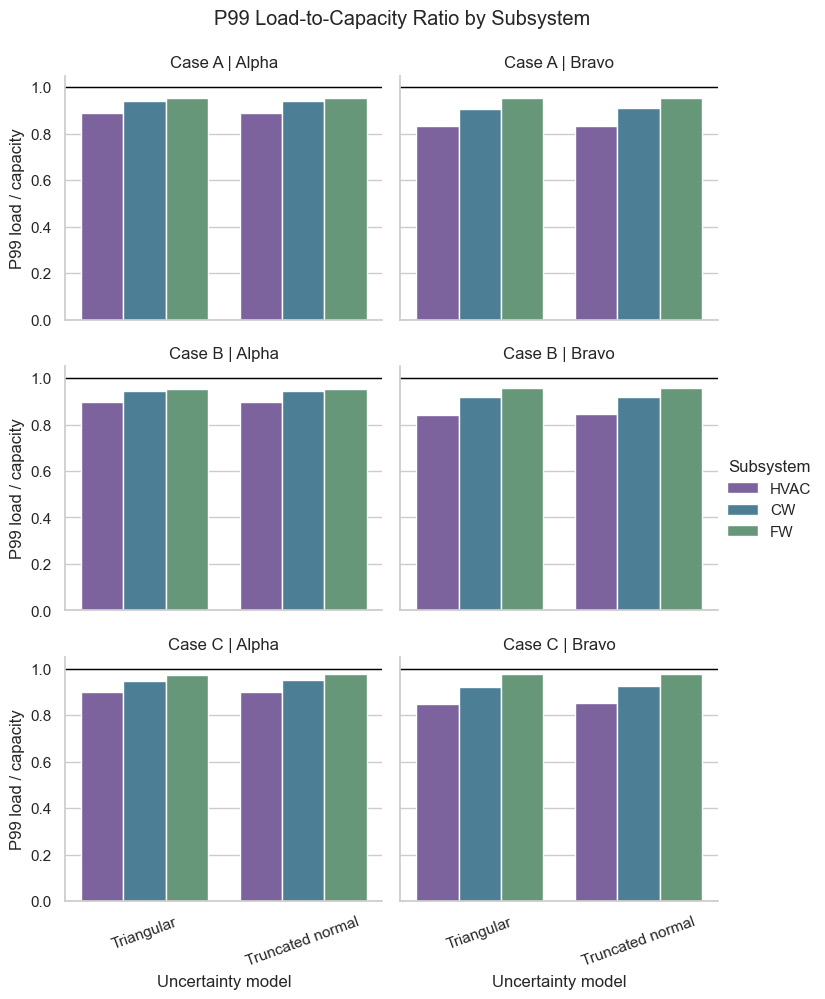

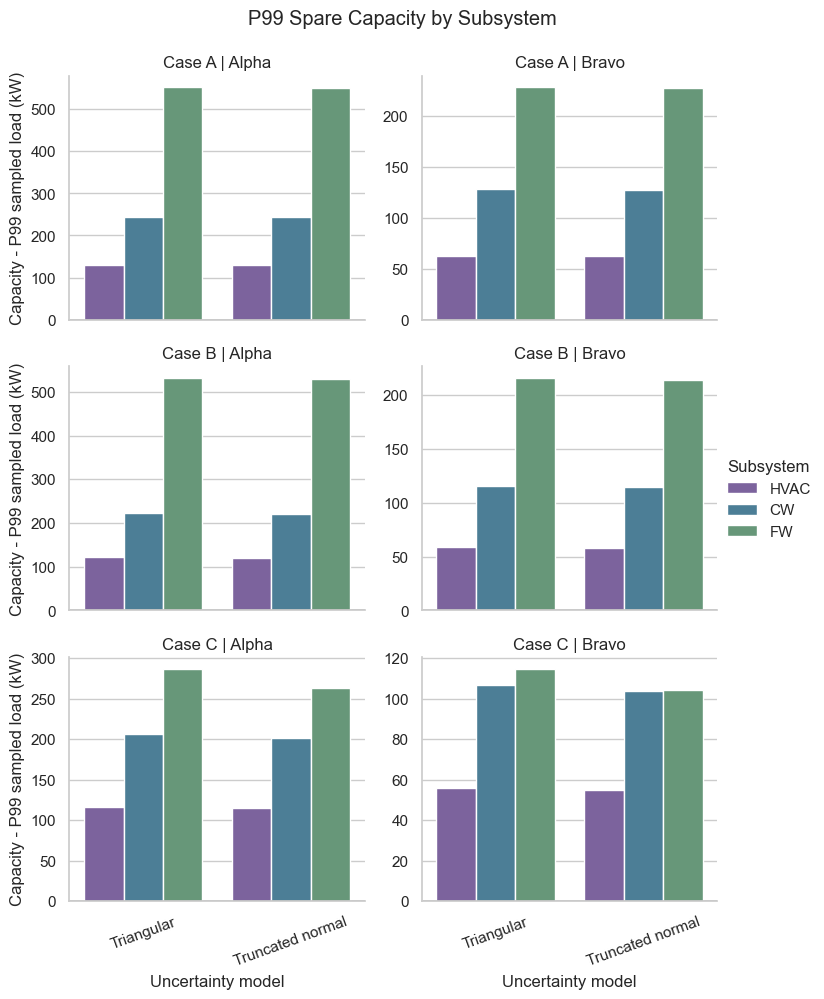

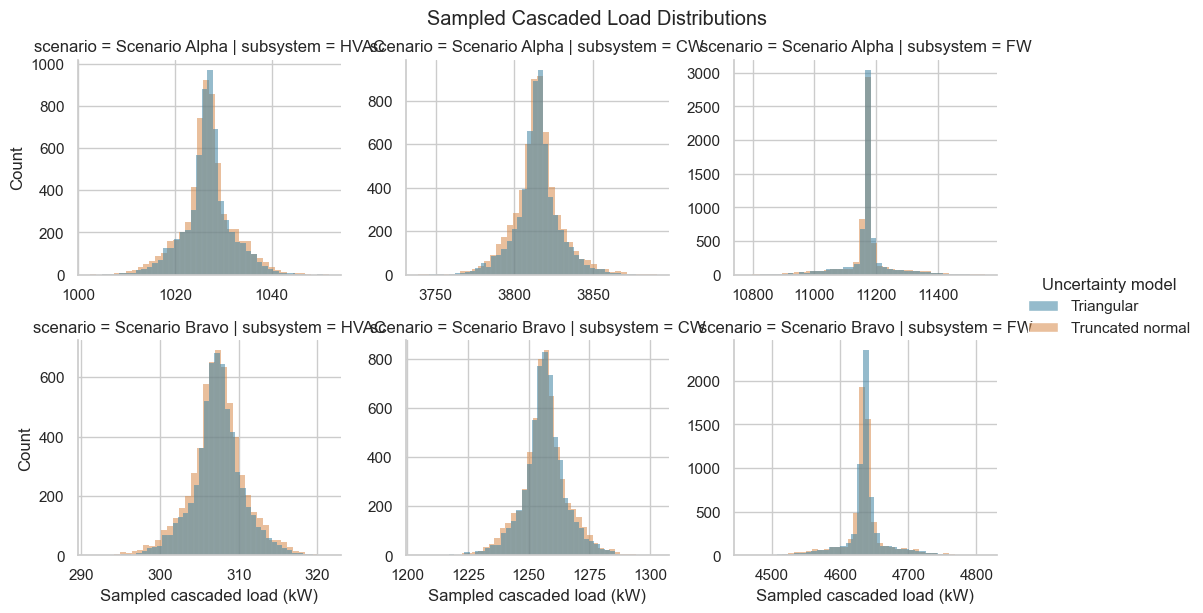

In [14]:
if plotting_available:
    sns.set_theme(style="whitegrid")

    if "monte_carlo_results" not in globals():
        monte_carlo_results = pd.read_csv(tables_output_path / "monte_carlo_results_summary.csv")
    if "monte_carlo_plot_samples" not in globals():
        monte_carlo_plot_samples = pd.read_csv(tables_output_path / "monte_carlo_plot_samples.csv")

    ratio_plot = monte_carlo_results.copy()
    ratio_plot["scenario_label"] = ratio_plot["scenario"].map({
        "Scenario Alpha": "Alpha",
        "Scenario Bravo": "Bravo",
    })
    ratio_plot["margin_case_label"] = ratio_plot["margin_case"].map({
        "Case A - CUM": "Case A",
        "Case B - CMM + CUM": "Case B",
        "Case C - CMM + CUM + DBM + IGM": "Case C",
    })

    graph = sns.catplot(
        data=ratio_plot,
        x="distribution_model",
        y="p99_load_to_capacity_ratio",
        hue="subsystem",
        row="margin_case_label",
        col="scenario_label",
        order=["Triangular", "Truncated normal"],
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        kind="bar",
        height=3.1,
        aspect=1.2,
        sharey=True,
    )
    graph.set_titles("{row_name} | {col_name}")
    graph.fig.suptitle("P99 Load-to-Capacity Ratio by Subsystem", y=1.03)
    graph.set_axis_labels("Uncertainty model", "P99 load / capacity")
    if graph._legend is not None:
        graph._legend.set_title("Subsystem")
    for axis in graph.axes.flat:
        axis.axhline(1.0, color="black", linewidth=1)
        axis.set_ylim(0, 1.05)
        axis.tick_params(axis="x", rotation=20)
    graph.savefig(
        figures_output_path / "monte_carlo_p99_load_to_capacity_ratio.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    spare_plot = monte_carlo_results.copy()
    spare_plot["scenario_label"] = spare_plot["scenario"].map({
        "Scenario Alpha": "Alpha",
        "Scenario Bravo": "Bravo",
    })
    spare_plot["margin_case_label"] = spare_plot["margin_case"].map({
        "Case A - CUM": "Case A",
        "Case B - CMM + CUM": "Case B",
        "Case C - CMM + CUM + DBM + IGM": "Case C",
    })

    graph = sns.catplot(
        data=spare_plot,
        x="distribution_model",
        y="p99_spare_capacity_kw",
        hue="subsystem",
        row="margin_case_label",
        col="scenario_label",
        order=["Triangular", "Truncated normal"],
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        kind="bar",
        height=3.1,
        aspect=1.2,
        sharey=False,
    )
    graph.set_titles("{row_name} | {col_name}")
    graph.fig.suptitle("P99 Spare Capacity by Subsystem", y=1.03)
    graph.set_axis_labels("Uncertainty model", "Capacity - P99 sampled load (kW)")
    if graph._legend is not None:
        graph._legend.set_title("Subsystem")
    for axis in graph.axes.flat:
        axis.axhline(0, color="black", linewidth=1)
        axis.tick_params(axis="x", rotation=20)
    graph.savefig(
        figures_output_path / "monte_carlo_p99_spare_capacity.png",
        dpi=150,
        bbox_inches="tight",
    )
    graph.savefig(
        figures_output_path / "monte_carlo_high_percentile_spare_capacity.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    graph = sns.displot(
        data=monte_carlo_plot_samples,
        x="sampled_load_kw",
        hue="distribution_model",
        row="scenario",
        col="subsystem",
        col_order=SYSTEM_ORDER,
        hue_order=["Triangular", "Truncated normal"],
        palette=DISTRIBUTION_PALETTE,
        kind="hist",
        bins=40,
        common_bins=False,
        facet_kws={"sharex": False, "sharey": False},
        alpha=0.55,
        height=3.0,
        aspect=1.15,
    )
    graph.fig.suptitle("Sampled Cascaded Load Distributions", y=1.02)
    graph.set_axis_labels("Sampled cascaded load (kW)", "Count")
    if graph._legend is not None:
        graph._legend.set_title("Uncertainty model")
    graph.savefig(
        figures_output_path / "monte_carlo_sampled_load_distributions.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Skipping plots because matplotlib and seaborn are not installed in this Python environment.")


## Interpretation

The first risk ranking is based on P99 load-to-capacity ratio and P99 spare capacity. Because no overloads were observed, these high-percentile margin metrics are more informative than plotting overload probability alone.


In [15]:
most_constrained = (
    monte_carlo_results
    .sort_values(
        ["p99_load_to_capacity_ratio", "p99_spare_capacity_kw"],
        ascending=[False, True],
    )
    .head(10)
    [[
        "scenario",
        "margin_case",
        "distribution_model",
        "subsystem",
        "capacity_kw",
        "p95_load_kw",
        "p99_load_kw",
        "p95_spare_capacity_kw",
        "p99_spare_capacity_kw",
        "p99_capacity_margin_pct",
        "p99_load_to_capacity_ratio",
        "overload_probability_pct",
        "rule_of_three_upper_if_zero",
    ]]
    .reset_index(drop=True)
)

most_constrained.to_csv(tables_output_path / "monte_carlo_most_constrained_cases.csv", index=False)
display(most_constrained)


,scenario,margin_case,distribution_model,subsystem,capacity_kw,p95_load_kw,p99_load_kw,p95_spare_capacity_kw,p99_spare_capacity_kw,p99_capacity_margin_pct,p99_load_to_capacity_ratio,overload_probability_pct,rule_of_three_upper_if_zero
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,FW,4871.78,4734.001511,4767.600336,137.778489,104.179664,2.138431,0.978616,0.0,0.00003
1,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,FW,11734.66,11392.385372,11471.478774,342.274628,263.181226,2.242768,0.977572,0.0,0.00003
2,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,FW,4871.78,4726.368742,4757.086339,145.411258,114.693661,2.354245,0.976458,0.0,0.00003
3,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,FW,11734.66,11374.327826,11447.679492,360.332174,286.980508,2.445580,0.975544,0.0,0.00003
4,Scenario Bravo,Case B - CMM + CUM,Truncated normal,FW,4871.78,4651.558500,4657.691806,220.221500,214.088194,4.394455,0.956055,0.0,0.00003
5,Scenario Bravo,Case B - CMM + CUM,Triangular,FW,4871.78,4650.383948,4656.208619,221.396052,215.571381,4.424900,0.955751,0.0,0.00003
6,Scenario Alpha,Case B - CMM + CUM,Truncated normal,FW,11734.66,11195.762154,11205.562284,538.897846,529.097716,4.508846,0.954912,0.0,0.00003
7,Scenario Alpha,Case B - CMM + CUM,Triangular,FW,11734.66,11193.917914,11202.877427,540.742086,531.782573,4.531725,0.954683,0.0,0.00003
8,Scenario Bravo,Case A - CUM,Truncated normal,FW,4871.78,4642.280183,4644.662288,229.499817,227.117712,4.661904,0.953381,0.0,0.00003
9,Scenario Bravo,Case A - CUM,Triangular,FW,4871.78,4641.804048,4643.998849,229.975952,227.781151,4.675522,0.953245,0.0,0.00003


## Notebook 05 conclusion

This notebook runs the independent Monte Carlo simulation using the uncertainty parameters defined in Notebook 04. The main result is that no subsystem overloads are observed when item loads are sampled independently.

The absence of overloads does not mean uncertainty can be ignored. The P99 spare-capacity and load-to-capacity results show which subsystem has the least margin under sampled load conditions. This gives a more useful comparison between HVAC, CW and FW before dependency is introduced in Notebook 06.